# Jason Brownlee's "Your First Machine Learning Project in R Step-By-Step" for 5b
### Shivani Dighamber
### digh04@osumc.edu
### 2 August 2026

## 1. Downloading Installing and Starting R
### 1.1 Download R
### 1.2 Install R
### 1.3 Start R
### 1.4 Install Packages
The following demonstrates how to prepare the R notebook. With proper preparation, it is verified whether the tutorial can be properly done.

In [1]:
library(caret)

Loading required package: ggplot2

Loading required package: lattice



## 2. Load The Data
### 2.1 Load Data The Easy Way
Here, the data is loaded for the tutorial. The dataset iris will be used.

In [2]:
# attach the iris dataset to the environment
data(iris)
# rename the dataset
dataset <- iris

### 2.2 Load From CSV
Additionally, there is the option to load the data from the project directory. The data utilized will be from iris.csv.

In [3]:
# define the filename
filename <- "iris.csv"
# load the CSV file from the local directory
dataset <- read.csv(filename, header=FALSE)
# set the column names in the dataset
colnames(dataset) <- c("Sepal.Length","Sepal.Width","Petal.Length","Petal.Width","Species")

### 2.3. Create a Validation Dataset
The following demonstrates the data being split in two for future testing.

In [4]:
# create a list of 80% of the rows in the original dataset we can use for training
validation_index <- createDataPartition(dataset$Species, p=0.80, list=FALSE)
# select 20% of the data for validation
validation <- dataset[-validation_index,]
# use the remaining 80% of data to training and testing the models
dataset <- dataset[validation_index,]

## 3. Summarize Dataset
### 3.1 Dimensions of Dataset
The next section will actually begin to uncover the dataset that is in use. The various ways to go about this are noted as follows, beginning with a simple display of instances and attributes.

In [5]:
# dimensions of dataset
dim(dataset)

[1] 120   5

### 3.2 Types of Attributes
Here, the different types of attributes can be noted.

In [6]:
# list types for each attribute
sapply(dataset, class)

Sepal.Length  Sepal.Width Petal.Length  Petal.Width      Species 
   "numeric"    "numeric"    "numeric"    "numeric"  "character"

### 3.3 Peek at the Data
This shows a more in-depth look at the dataset.

In [7]:
# take a peek at the first 5 rows of the data
head(dataset)

,Sepal.Length,Sepal.Width,Petal.Length,Petal.Width,Species
,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
2,4.9,3.0,1.4,0.2,Iris-setosa
3,4.7,3.2,1.3,0.2,Iris-setosa
4,4.6,3.1,1.5,0.2,Iris-setosa
5,5.0,3.6,1.4,0.2,Iris-setosa
7,4.6,3.4,1.4,0.3,Iris-setosa
9,4.4,2.9,1.4,0.2,Iris-setosa


### 3.4 Levels of the Class
Here, the factor class variable is studied.

In [8]:
# list the levels for the class
dataset$Species <- as.factor(dataset$Species)
levels(dataset$Species)

[1] "Iris-setosa"     "Iris-versicolor" "Iris-virginica"

### 3.5 Class Distribution
The following demonstrates the instances in respect to their given class.

In [9]:
# summarize the class distribution
percentage <- prop.table(table(dataset$Species)) * 100
cbind(freq=table(dataset$Species), percentage=percentage)

,freq,percentage
Iris-setosa,40,33.33333
Iris-versicolor,40,33.33333
Iris-virginica,40,33.33333


### 3.6 Statistical Summary
The attributes can then have a summary created as follows.

In [10]:
# summarize attribute distributions
summary(dataset)

  Sepal.Length    Sepal.Width     Petal.Length    Petal.Width   
 Min.   :4.400   Min.   :2.000   Min.   :1.000   Min.   :0.100  
 1st Qu.:5.100   1st Qu.:2.775   1st Qu.:1.500   1st Qu.:0.300  
 Median :5.750   Median :3.000   Median :4.250   Median :1.300  
 Mean   :5.809   Mean   :3.035   Mean   :3.739   Mean   :1.185  
 3rd Qu.:6.400   3rd Qu.:3.300   3rd Qu.:5.100   3rd Qu.:1.800  
 Max.   :7.900   Max.   :4.400   Max.   :6.900   Max.   :2.500  
            Species  
 Iris-setosa    :40  
 Iris-versicolor:40  
 Iris-virginica :40  
                     
                     
                     

## 4. Visualize Dataset
### 4.1 Univariate Plots
In this section, visualizations are represented. Here, both univariate and multivariate plotting is utilized. Univariate plotting allows for individual variables to be plotted.

In [11]:
# split input and output
x <- dataset[,1:4]
y <- dataset[,5]

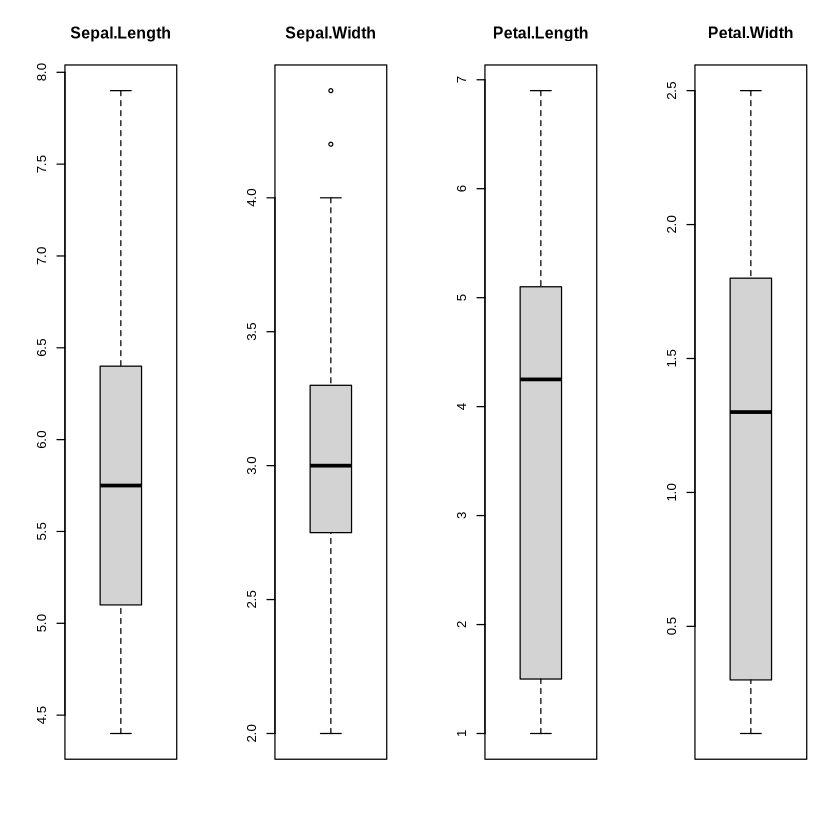

In [12]:
# boxplot for each attribute on one image
par(mfrow=c(1,4))
  for(i in 1:4) {
  boxplot(x[,i], main=names(iris)[i])
}

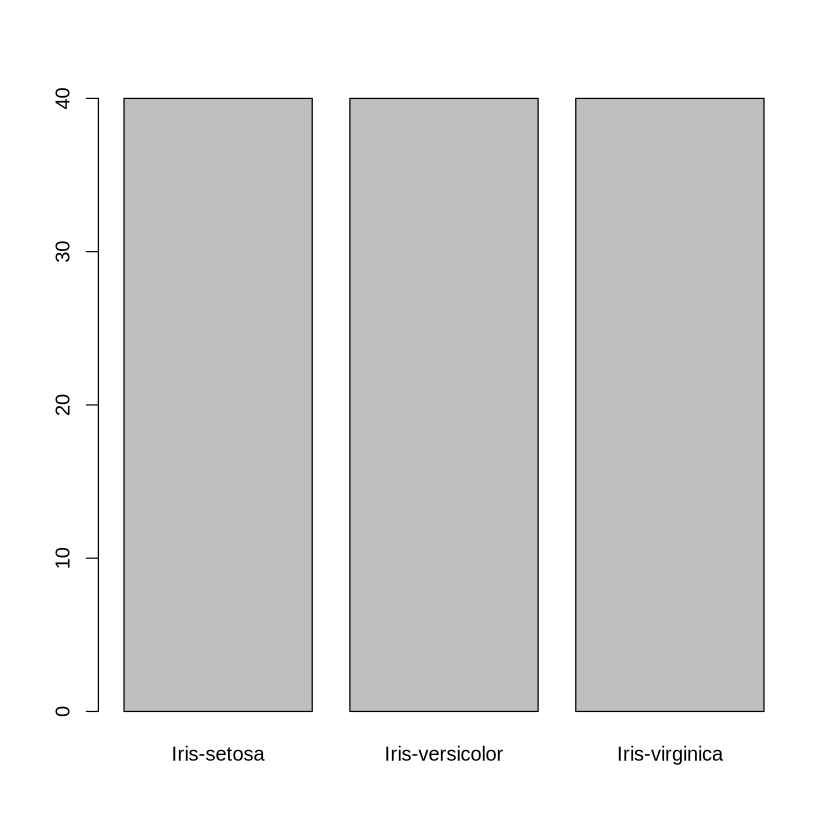

In [13]:
# barplot for class breakdown
plot(y)

### 4.2 Multivariate Plots
Multivariate plotting allows for variable relationships to be studied. Note the Gaussian-like distribution.

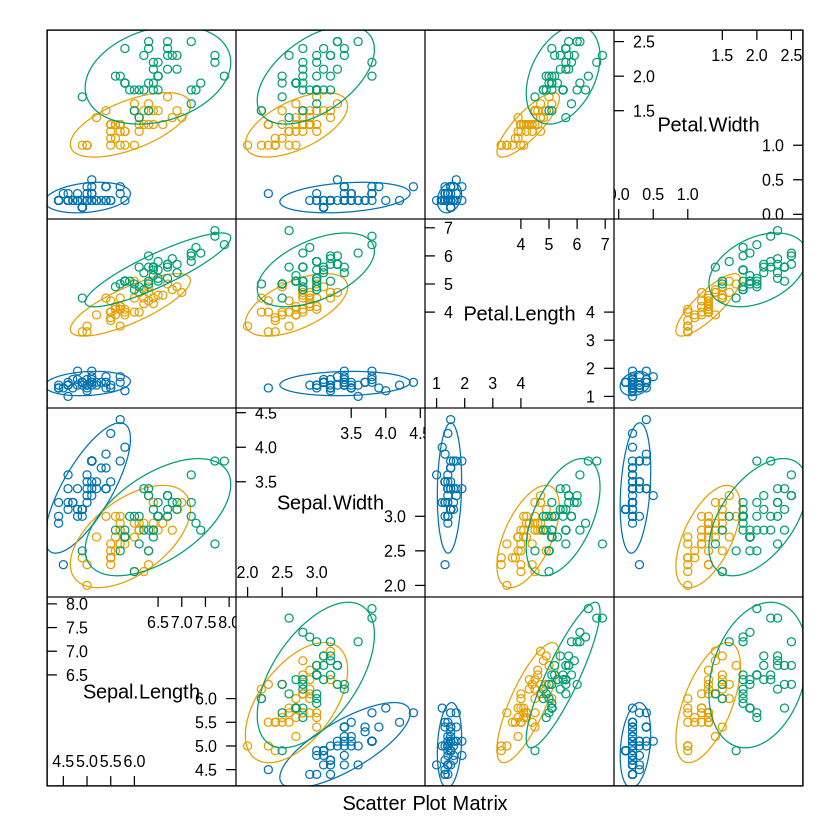

In [14]:
# scatterplot matrix
featurePlot(x=x, y=y, plot="ellipse")

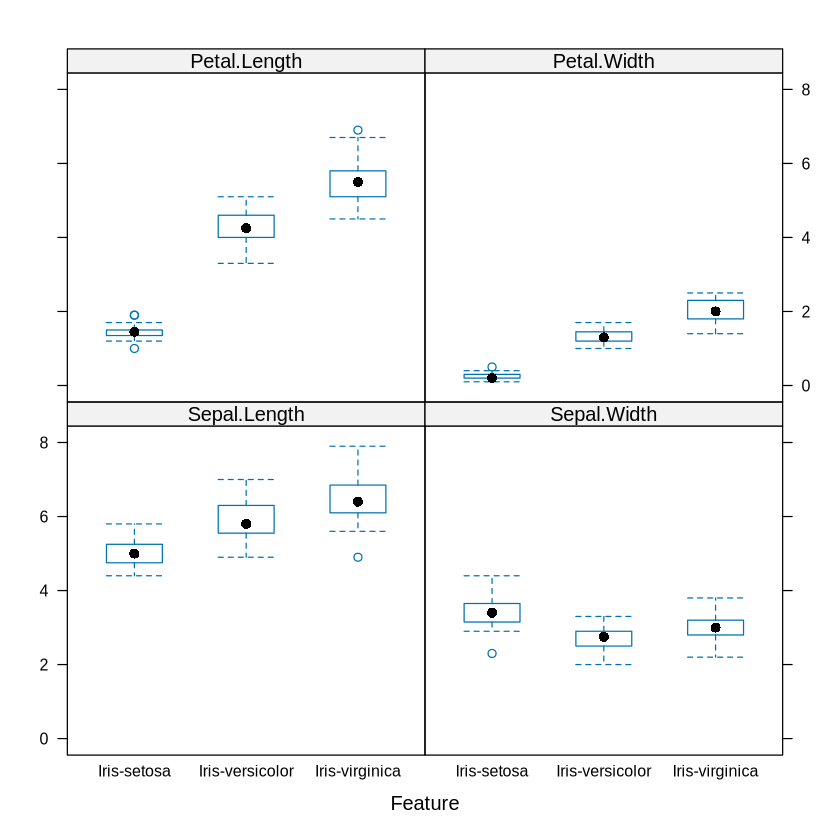

In [15]:
# box and whisker plots for each attribute
featurePlot(x=x, y=y, plot="box")

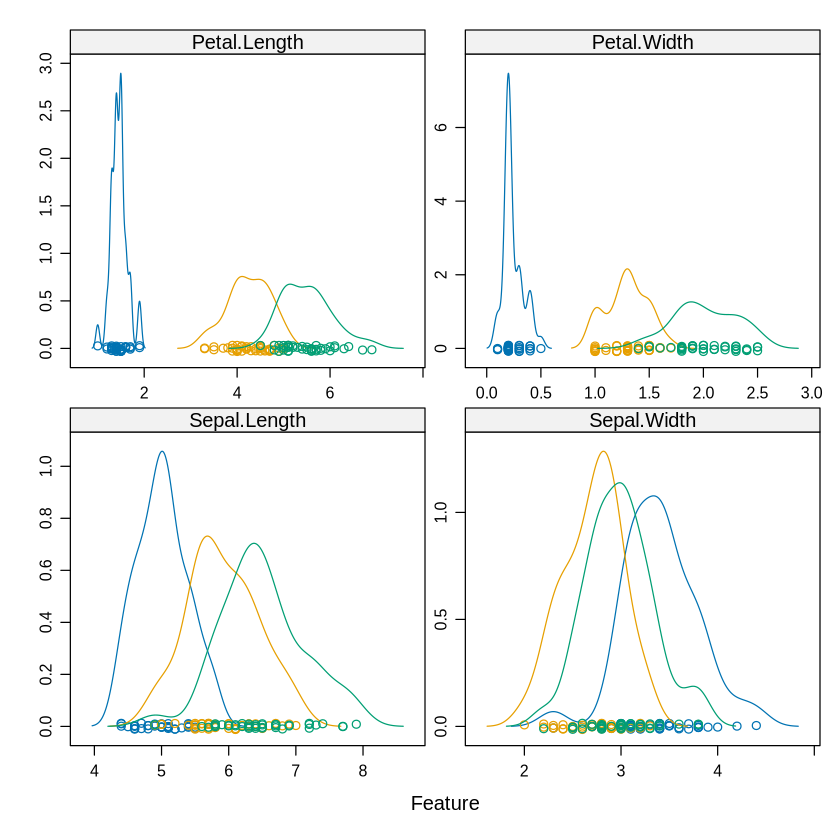

In [16]:
# density plots for each attribute by class value
scales <- list(x=list(relation="free"), y=list(relation="free"))
featurePlot(x=x, y=y, plot="density", scales=scales)

## 5. Evaluate Some Algorithms
### 5.1 Test Harness
This section puts to use the accumulated data by testing its replicability strength. The following demonstrates how the 10-fold cross validation is stratified. 

In [17]:
# Run algorithms using 10-fold cross validation
control <- trainControl(method="cv", number=10)
metric <- "Accuracy"

### 5.2 Build Models
Different models are utilized to assess what is best to use. Both simple and nonlinear algorithms are utilized.

In [18]:
# a) linear algorithms
set.seed(7)
fit.lda <- train(Species~., data=dataset, method="lda", metric=metric, trControl=control)
# b) nonlinear algorithms
# CART
set.seed(7)
fit.cart <- train(Species~., data=dataset, method="rpart", metric=metric, trControl=control)
# kNN
set.seed(7)
fit.knn <- train(Species~., data=dataset, method="knn", metric=metric, trControl=control)
# c) advanced algorithms
# SVM
set.seed(7)
fit.svm <- train(Species~., data=dataset, method="svmRadial", metric=metric, trControl=control)
# Random Forest
set.seed(7)
fit.rf <- train(Species~., data=dataset, method="rf", metric=metric, trControl=control)

### 5.3 Select Best Model
The most accurate model is chosen here. Note the chosen model LDA here.

In [19]:
# summarize accuracy of models
results <- resamples(list(lda=fit.lda, cart=fit.cart, knn=fit.knn, svm=fit.svm, rf=fit.rf))
summary(results)


Call:
summary.resamples(object = results)

Models: lda, cart, knn, svm, rf 
Number of resamples: 10 

Accuracy 
          Min.   1st Qu.    Median      Mean   3rd Qu. Max. NA's
lda  0.9166667 1.0000000 1.0000000 0.9833333 1.0000000    1    0
cart 0.8333333 0.9166667 0.9166667 0.9250000 0.9791667    1    0
knn  0.9166667 0.9375000 1.0000000 0.9750000 1.0000000    1    0
svm  0.8333333 0.9166667 0.9583333 0.9500000 1.0000000    1    0
rf   0.8333333 0.9166667 1.0000000 0.9583333 1.0000000    1    0

Kappa 
      Min. 1st Qu. Median   Mean 3rd Qu. Max. NA's
lda  0.875 1.00000 1.0000 0.9750 1.00000    1    0
cart 0.750 0.87500 0.8750 0.8875 0.96875    1    0
knn  0.875 0.90625 1.0000 0.9625 1.00000    1    0
svm  0.750 0.87500 0.9375 0.9250 1.00000    1    0
rf   0.750 0.87500 1.0000 0.9375 1.00000    1    0


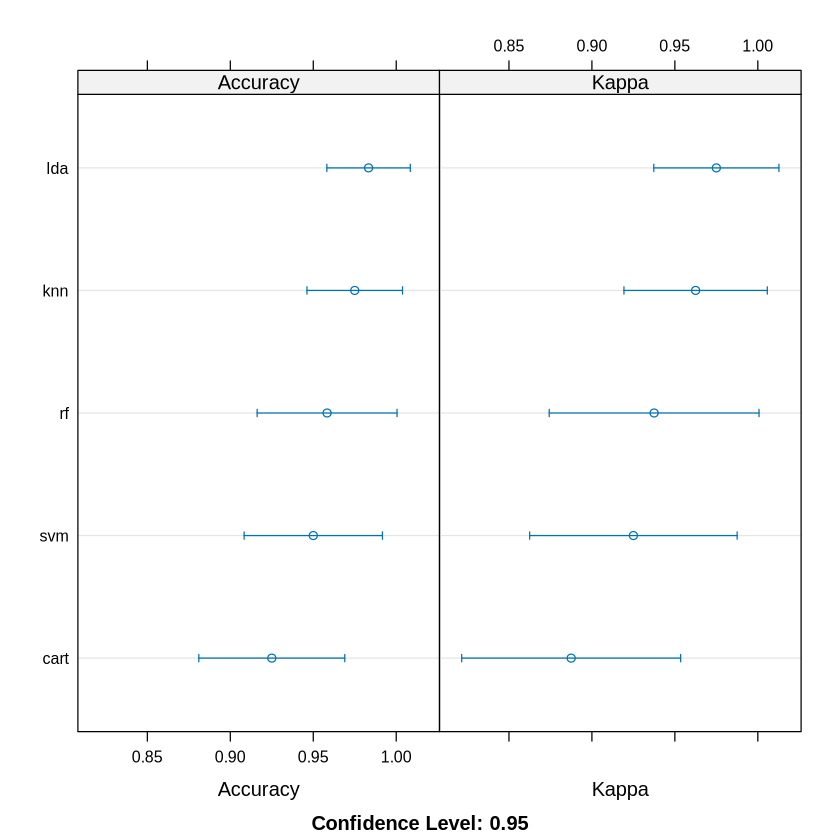

In [20]:
# compare accuracy of models
dotplot(results)

In [21]:
# summarize Best Model
print(fit.lda)

Linear Discriminant Analysis 

120 samples
  4 predictor
  3 classes: 'Iris-setosa', 'Iris-versicolor', 'Iris-virginica' 

No pre-processing
Resampling: Cross-Validated (10 fold) 
Summary of sample sizes: 108, 108, 108, 108, 108, 108, ... 
Resampling results:

  Accuracy   Kappa
  0.9833333  0.975



## 6. Make Predictions
The most accurate algorithm from the previous section is used in this section for predictions.

In [22]:
# estimate skill of LDA on the validation dataset
validation$Species <- as.factor(validation$Species)
predictions <- predict(fit.lda, validation)
confusionMatrix(predictions, validation$Species)

Confusion Matrix and Statistics

                 Reference
Prediction        Iris-setosa Iris-versicolor Iris-virginica
  Iris-setosa              10               0              0
  Iris-versicolor           0               9              0
  Iris-virginica            0               1             10

Overall Statistics
                                          
               Accuracy : 0.9667          
                 95% CI : (0.8278, 0.9992)
    No Information Rate : 0.3333          
    P-Value [Acc > NIR] : 2.963e-13       
                                          
                  Kappa : 0.95            
                                          
 Mcnemar's Test P-Value : NA              

Statistics by Class:

                     Class: Iris-setosa Class: Iris-versicolor
Sensitivity                      1.0000                 0.9000
Specificity                      1.0000                 1.0000
Pos Pred Value                   1.0000                 1.0000
Neg Pred Value